In [126]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 15,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_KLs_squared_norms_ID = {"npe_c": 3,
                                  "tsnpe": 3,
                                  "nle_mcmc": 3,
                                  "nle_vi": 3,
                                  "nre": 3} # The ID of the experiment in each algorithm directory
algorithm_names_to_nice = {"npe_c": "SNPE-C",
                                  "tsnpe": "TSNPE",
                                  "nle_mcmc": "SNLE-MCMC",
                                  "nle_vi": "SNLE-VI",
                                  "nre": "SNRE-B"}

In [127]:
squared_norms_dicts = {}
KLs_squared_norms_configs = {}

for algorithm_name in algorithm_names:
    KLs_squared_norms_ID = algorithm_KLs_squared_norms_ID[algorithm_name]

    results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
    config_path = results_path + f"/KLs_squared_norms{KLs_squared_norms_ID}.yaml"
    squared_norms_path = results_path + f"/KLs_squared_norms{KLs_squared_norms_ID}_squared_norms_dict.npz"

    # Load config
    with open(config_path, "r") as f:
        KLs_squared_norms_config = yaml.safe_load(f)
    KLs_squared_norms_configs[algorithm_name] = KLs_squared_norms_config

    # Load squared norms
    squared_norms_dict_ = dict(np.load(squared_norms_path))
    squared_norms_dicts[algorithm_name] = squared_norms_dict_



In [128]:
def plot_training_parameter_squared_norms(squared_norms_dict, d, exclude_rounds=None, alpha=0.1, title=None, ax=None, include_legend=True):
    if exclude_rounds is None:
        exclude_rounds = []
    user_defined_ax = ax is not None
    if not user_defined_ax:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_xlabel("Round")
        ax.set_ylabel(r"$||\theta||^2_2$ where $\theta \sim \tilde{\pi}_r(\theta|x)$")
    if title is None:
        pass
        #ax.set_title(f"Mean and quantiles of $||\\theta||^2_2$ (±2 SE) from posterior approximation at each round")
    else:
        ax.set_title(title)
    ax.set_prop_cycle(None)

    mean_means = []
    mean_lqs = []
    mean_uqs = []

    se_means = []
    se_lqs = []
    se_uqs = []

    rs = []

    r = 0
    while f"round_{r}" in squared_norms_dict:
        if r not in exclude_rounds:
            squared_norms = squared_norms_dict[f"round_{r}"]
            # shape: (num_repetitions, num_simulations_per_round)

            # Per-repetition statistics
            means = np.mean(squared_norms, axis=1)
            lqs = np.quantile(squared_norms, alpha / 2, axis=1)
            uqs = np.quantile(squared_norms, 1 - alpha / 2, axis=1)

            R = len(means)

            # Averages across repetitions
            mean_means.append(np.mean(means))
            mean_lqs.append(np.mean(lqs))
            mean_uqs.append(np.mean(uqs))

            # Standard errors across repetitions
            se_means.append(np.std(means, ddof=1) / np.sqrt(R))
            se_lqs.append(np.std(lqs, ddof=1) / np.sqrt(R))
            se_uqs.append(np.std(uqs, ddof=1) / np.sqrt(R))

            rs.append(r)

        r += 1

    rs = np.array(rs) + 1 # 1 index the rounds

    mean_means = np.array(mean_means)
    mean_lqs = np.array(mean_lqs)
    mean_uqs = np.array(mean_uqs)

    se_means = np.array(se_means)
    se_lqs = np.array(se_lqs)
    se_uqs = np.array(se_uqs)

    # True values
    true_lq = scipy.stats.chi2.ppf(alpha / 2, df=d)
    true_uq = scipy.stats.chi2.ppf(1 - alpha / 2, df=d)

    # Plot mean with ±1 SE
    ax.errorbar(
        rs,
        mean_means,
        yerr=2 * se_means,
        fmt="o",
        capsize=4,
        markersize=4,
        label="Approx. mean",
    )

    # Plot lower quantile with ±1 SE
    ax.errorbar(
        rs,
        mean_lqs,
        yerr=2 * se_lqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approx. {100*alpha/2:.1f}% quantile",
    )

    # Plot upper quantile with ±1 SE
    ax.errorbar(
        rs,
        mean_uqs,
        yerr=2 * se_uqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approx. {100*(1-alpha/2):.1f}% quantile",
    )

    ax.axhline(d, color="k", linestyle="--", label="True mean")
    ax.fill_between(rs, true_lq, true_uq, alpha=0.2, color="gray",
                    label=f"{100*alpha/2:.1f}% and {100*(1-alpha/2):.1f}% quantile")

    ax.vlines(
        rs,
        mean_lqs,
        mean_uqs,
        colors="gray",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )

    ax.set_xticks(rs)
    if include_legend:
        ax.legend(fontsize=9)
    return ax

In [129]:
from copy import copy
# MOVE TO SRC CODE WHEN HAPPY
def plot_training_parameter_squared_norms_hist(squared_norms_dict, d, exclude_rounds=None, alpha=0.1, bins=None, histtype="step", title=None, ax=None, include_legend=True):
    # ONLY WORKS WITH ONE REPETITION
    if squared_norms_dict["round_0"].ndim > 1:
        # If we have multiple samples, we only consider the first one
        squared_norms_dict_ = {}
        for k, v in squared_norms_dict.items():
            squared_norms_dict_[k] = v[0,:]
    else:
        squared_norms_dict_ = copy(squared_norms_dict)

    # List of rounds to exclude from plot
    if exclude_rounds is None:
        exclude_rounds = []
    user_defined_ax = ax is not None
    if not user_defined_ax:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_xlabel(r"$||\theta||^2$")
        ax.set_ylabel("Density")
    ax.set_prop_cycle(None)
    r = 0
    while f"round_{r}" in squared_norms_dict_:
        if not r in exclude_rounds:
            #color = plt.gca()._get_lines.get_next_color()
            color = ax._get_lines.get_next_color()
            squared_norms = squared_norms_dict_[f"round_{r}"]
            if bins is not None:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r+1}", bins=bins, color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, bins=bins, color=color, label=f"Round {r+1}", histtype=histtype)
            else:
                if histtype == "bar":
                    ax.hist(squared_norms, alpha=alpha, density=True, label=f"Round {r+1}", color=color, histtype=histtype)
                elif histtype == "step":
                    ax.hist(squared_norms, density=True, color=color, label=f"Round {r+1}", histtype=histtype)
        r += 1
    xl, xu = ax.get_xlim()
    x_range = np.linspace(xl, xu, 1000)
    ax.plot(x_range, scipy.stats.chi2.pdf(x_range, df=d), color="k", label=r"pdf of $\chi^2_d$")
    if title is None:
        pass
        #ax.set_title(r"Distribution of $||\theta||_2^2$ where $\theta \sim \tilde{\pi}_r(\theta|x)$ for each round")
    else:
        ax.set_title(title)
    if include_legend:
        ax.legend(fontsize=9)
    return ax

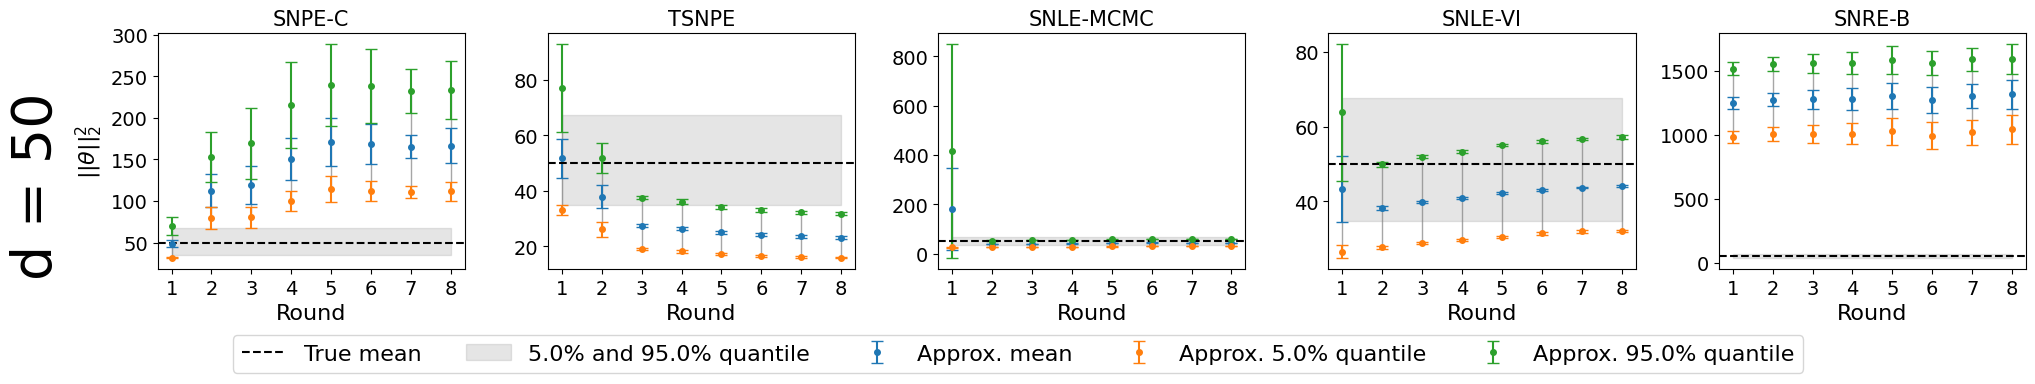

In [130]:
fig, ax = plt.subplots(figsize=(20, 4), ncols=5)
for j in range(5):
    algorithm_name = algorithm_names[j]
    squared_norms_dict = squared_norms_dicts[algorithm_name]
    title = algorithm_names_to_nice[algorithm_name]
    d = KLs_squared_norms_configs[algorithm_name]["d"]
    include_legend = False
    plot_training_parameter_squared_norms(squared_norms_dict, d=d, exclude_rounds=[], title=title, ax=ax[j], include_legend=False)
    ax[j].set_xlabel("Round")
    if j == 0:
        ax[j].set_ylabel(r"$||\theta||_2^2$")
# Add one legend for all subplots
handles, labels = ax[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.text(-0.02, 0.5, f"d = {d}", va='center', rotation=90, fontsize=40)
plt.tight_layout()
plt.subplots_adjust(bottom=0.29)  # top=0.75 leaves room for legend
plt.show()

In [ ]:
algorithm_name = "tsnpe"
squared_norms_dict = squared_norms_dicts[algorithm_name]
d = KLs_squared_norms_configs[algorithm_name]["d"]

50


<Axes: title={'center': 'Mean and quantiles of $||\\theta||^2_2$ (±2 SE) from TSNPE posterior approximation at each round (d = 25)'}, xlabel='Round', ylabel='$||\\theta||^2_2$ where $\\theta \\sim \\tilde{\\pi}_r(\\theta|x)$'>

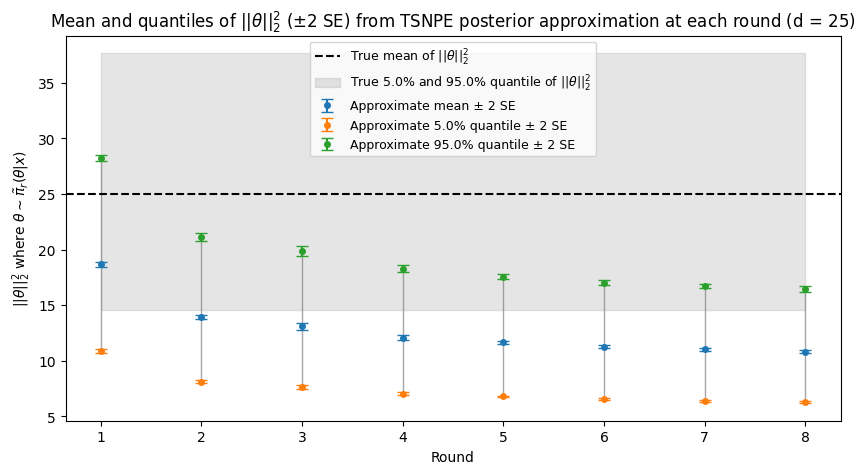

In [37]:
title = f"Mean and quantiles of $||\\theta||^2_2$ (±2 SE) from {algorithm_names_to_nice[algorithm_name]} posterior approximation at each round (d = {d})"
plot_training_parameter_squared_norms(squared_norms_dict, d=d, exclude_rounds=[], title=title)

<Axes: title={'center': '(TSNPE) Distribution of $||\\theta||_2^2$ where $\\theta \\sim \\tilde{\\pi}_r(\\theta|x)$ for each round (d = 25)'}, xlabel='$||\\theta||^2$', ylabel='Density'>

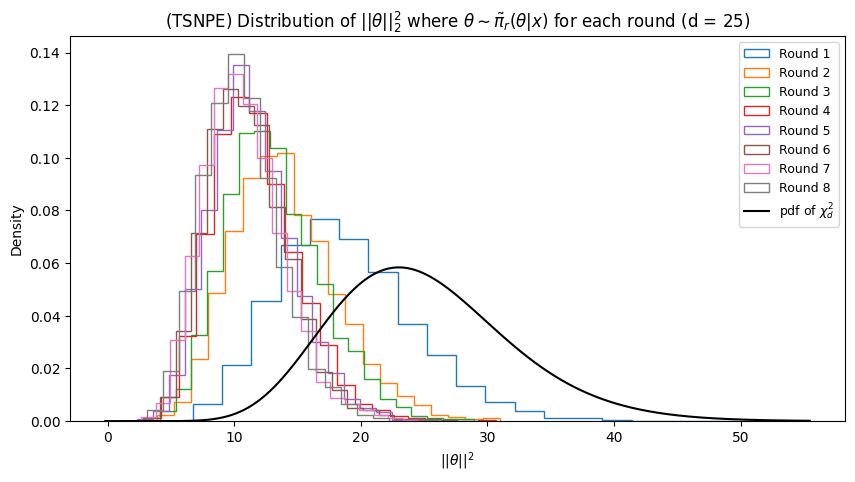

In [38]:
title = f"({algorithm_names_to_nice[algorithm_name]}) " + r"Distribution of $||\theta||_2^2$ where $\theta \sim \tilde{\pi}_r(\theta|x)$ for each round" + f" (d = {d})"
plot_training_parameter_squared_norms_hist(squared_norms_dict, d, alpha=0.7,
                                           exclude_rounds=[], bins=20, histtype="step", title=title)

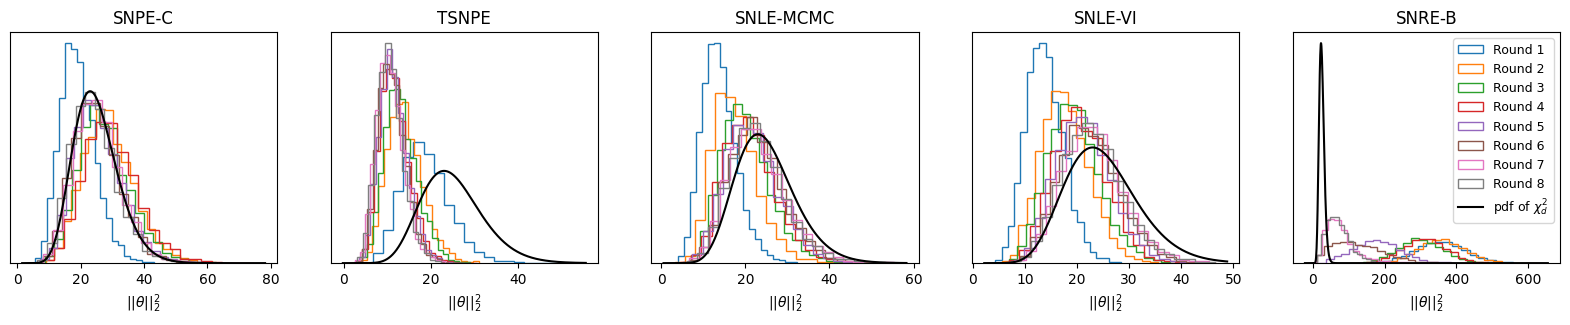

In [39]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5)
for j in range(5):
    algorithm_name = algorithm_names[j]
    squared_norms_dict = squared_norms_dicts[algorithm_name]
    title = algorithm_names_to_nice[algorithm_name]
    include_legend = False
    if j == 4:
        include_legend = True
    plot_training_parameter_squared_norms_hist(squared_norms_dict, d, alpha=0.7,
                                           exclude_rounds=[], bins=20, histtype="step", ax=ax[j], include_legend=include_legend, title=title)
    ax[j].set_yticks([])
    ax[j].set_xlabel(r"$||\theta||^2_2$")

